<a href="https://www.kaggle.com/code/sonawanelalitsunil/broadcom-stock-trends-2025-ml-100?scriptVersionId=228227305" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/broadcom-stock-data-2025/AVGO_2009-08-06_2025-03-15.csv


## Title: Broadcom Stock Trends 2025

### Description: Analyzing Broadcom's stock performance, trends, and key market movements in 2025.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/broadcom-stock-data-2025/AVGO_2009-08-06_2025-03-15.csv')

In [3]:
df.head()

,date,open,high,low,close,adj_close,volume
0,2009-08-06 00:00:00-04:00,1.650,1.691,1.556,1.618,1.150073,241978000
1,2009-08-07 00:00:00-04:00,1.615,1.676,1.603,1.643,1.167844,24543000
2,2009-08-10 00:00:00-04:00,1.663,1.663,1.561,1.597,1.135147,24210000
3,2009-08-11 00:00:00-04:00,1.598,1.600,1.550,1.567,1.113823,23054000
4,2009-08-12 00:00:00-04:00,1.615,1.620,1.566,1.600,1.137280,14513000


In [4]:
df.tail()

,date,open,high,low,close,adj_close,volume
3921,2025-03-10 00:00:00-04:00,189.600006,191.979996,180.429993,184.449997,184.449997,44217100
3922,2025-03-11 00:00:00-04:00,188.050003,195.619995,185.350006,190.089996,190.089996,42153200
3923,2025-03-12 00:00:00-04:00,196.220001,199.979996,192.449997,194.229996,194.229996,30409700
3924,2025-03-13 00:00:00-04:00,193.149994,196.320007,189.470001,191.360001,191.360001,27236100
3925,2025-03-14 00:00:00-04:00,196.199997,197.500000,193.199997,195.539993,195.539993,25881000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3926 entries, 0 to 3925
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       3926 non-null   object 
 1   open       3926 non-null   float64
 2   high       3926 non-null   float64
 3   low        3926 non-null   float64
 4   close      3926 non-null   float64
 5   adj_close  3926 non-null   float64
 6   volume     3926 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 214.8+ KB


In [6]:
df.describe()

,open,high,low,close,adj_close,volume
count,3926.000000,3926.000000,3926.000000,3926.000000,3926.000000,3.926000e+03
mean,34.262932,34.734434,33.737508,34.246686,31.742464,2.560513e+07
std,44.263089,44.951437,43.390624,44.163523,44.334985,2.076722e+07
min,1.460000,1.482000,1.433000,1.449000,1.029949,3.080000e+05
25%,3.774000,3.815250,3.728250,3.771500,2.769988,1.560325e+07
50%,21.809000,22.074500,21.623000,21.851501,17.432988,2.133850e+07
75%,46.158750,46.854502,45.607501,46.286000,42.438378,2.985975e+07
max,246.750000,251.880005,241.910004,250.000000,249.331955,5.602800e+08


In [7]:
df.isnull().sum()

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.corr

<bound method DataFrame.corr of                            date        open        high         low  \
0     2009-08-06 00:00:00-04:00    1.650000    1.691000    1.556000   
1     2009-08-07 00:00:00-04:00    1.615000    1.676000    1.603000   
2     2009-08-10 00:00:00-04:00    1.663000    1.663000    1.561000   
3     2009-08-11 00:00:00-04:00    1.598000    1.600000    1.550000   
4     2009-08-12 00:00:00-04:00    1.615000    1.620000    1.566000   
...                         ...         ...         ...         ...   
3921  2025-03-10 00:00:00-04:00  189.600006  191.979996  180.429993   
3922  2025-03-11 00:00:00-04:00  188.050003  195.619995  185.350006   
3923  2025-03-12 00:00:00-04:00  196.220001  199.979996  192.449997   
3924  2025-03-13 00:00:00-04:00  193.149994  196.320007  189.470001   
3925  2025-03-14 00:00:00-04:00  196.199997  197.500000  193.199997   

           close   adj_close     volume  
0       1.618000    1.150073  241978000  
1       1.643000    1.167844   

In [10]:
df.shape

(3926, 7)

In [11]:
df.dtypes

date          object
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object

In [12]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

## Data visualizations

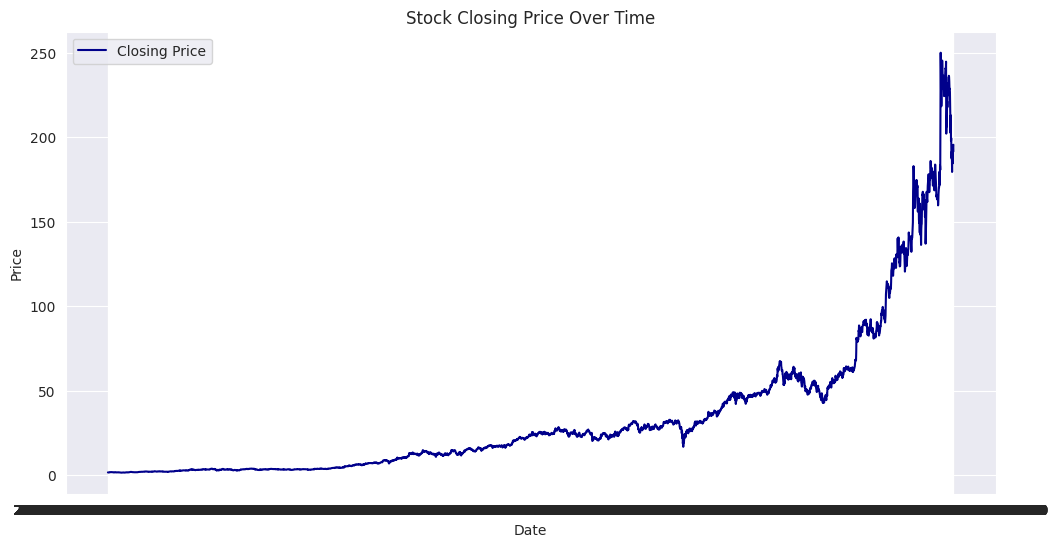

In [13]:
df.set_index('date', inplace=True)

# Set style
sns.set_style("darkgrid")
plt.figure(figsize=(12, 6))

# Line plot for closing prices
plt.plot(df.index, df['close'], label='Closing Price', color='darkblue')
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

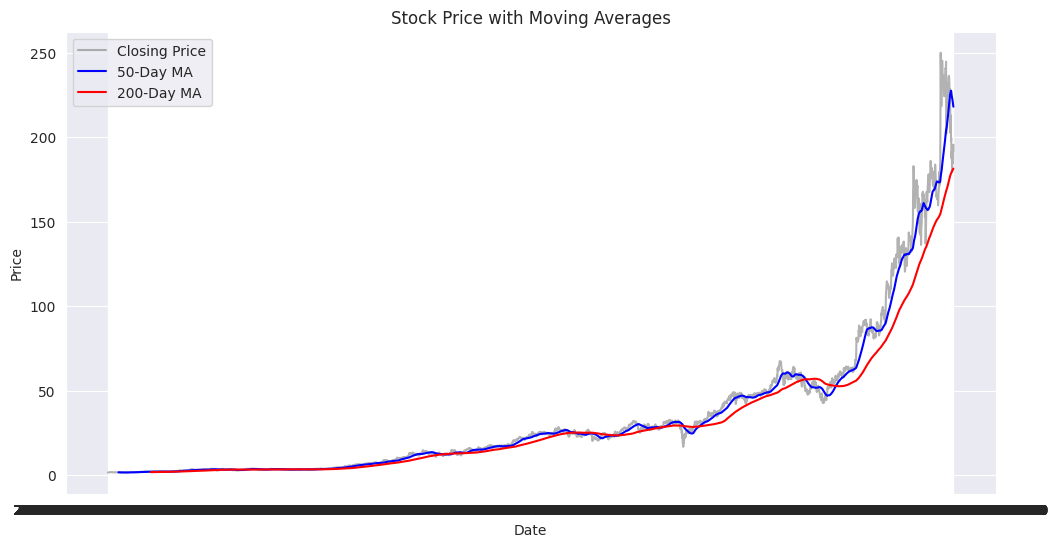

In [14]:
# Moving Average (50-day and 200-day) Trend
plt.figure(figsize=(12, 6))
df['MA_50'] = df['close'].rolling(window=50).mean()
df['MA_200'] = df['close'].rolling(window=200).mean()
plt.plot(df.index, df['close'], label='Closing Price', color='gray', alpha=0.6)
plt.plot(df.index, df['MA_50'], label='50-Day MA', color='blue')
plt.plot(df.index, df['MA_200'], label='200-Day MA', color='red')
plt.title("Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

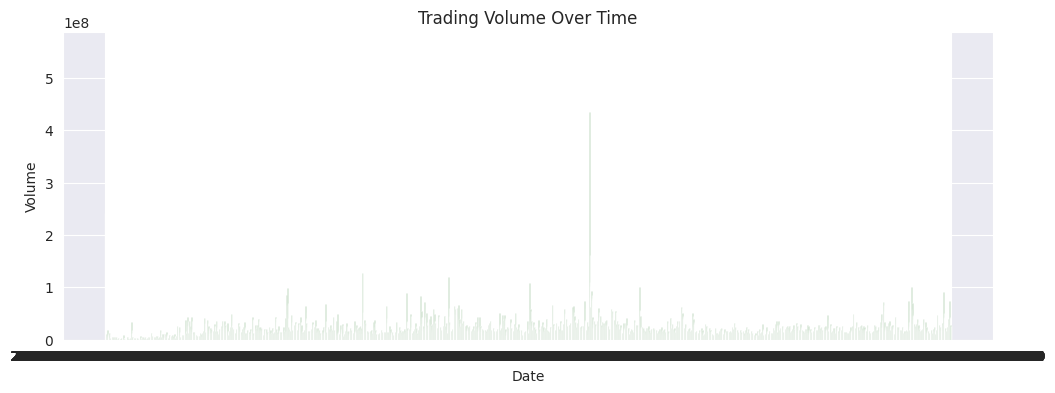

In [15]:
# Volume Traded Over Time
plt.figure(figsize=(12, 4))
plt.bar(df.index, df['volume'], color='darkgreen', alpha=0.6)
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

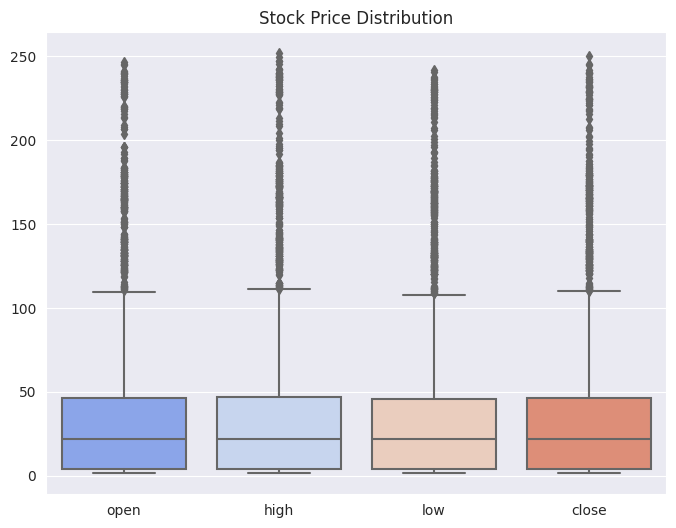

In [16]:
# Boxplot for Price Distribution
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['open', 'high', 'low', 'close']], palette='coolwarm')
plt.title("Stock Price Distribution")
plt.show()

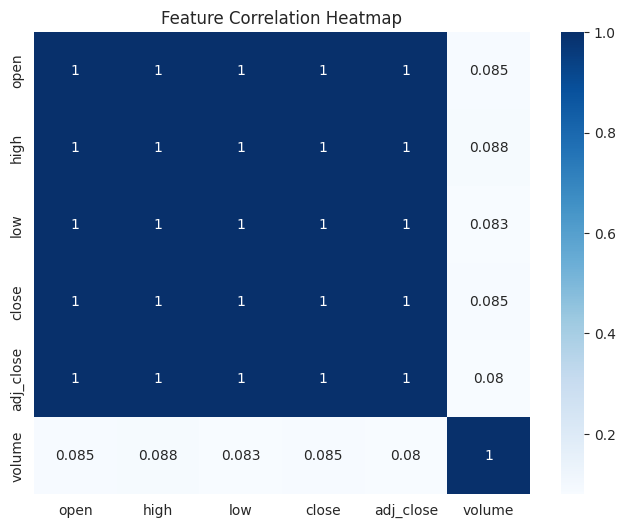

In [17]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['open', 'high', 'low', 'close', 'adj_close', 'volume']].corr(), annot=True, cmap='Blues')
plt.title("Feature Correlation Heatmap")
plt.show()

## predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [19]:
print(df.columns)

Index(['open', 'high', 'low', 'close', 'adj_close', 'volume', 'MA_50',
       'MA_200'],
      dtype='object')


In [20]:
# Define features and target
X = df.drop(columns=['close'])
y = df['close']

In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.impute import SimpleImputer
import numpy as np

# Handle missing values by imputing with the mean
imputer = SimpleImputer(strategy='mean')  # Change to 'median' or 'most_frequent' if needed
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)  # Apply the same transformation to test data

In [23]:
# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}


In [25]:
# Ensure X_train and X_test are DataFrames
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Apply imputation
imputer = SimpleImputer(strategy='mean')
X_train[:] = imputer.fit_transform(X_train)
X_test[:] = imputer.transform(X_test)

# Convert to NumPy (optional, depending on model needs)
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

In [26]:
# Train and evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, mse, rmse, r2])

# Display results
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"])
print(results_df.sort_values(by='R2 Score', ascending=False))

                      Model       MAE         MSE       RMSE  R2 Score
1             Random Forest  0.184650    0.172427   0.415243  0.999922
0         Linear Regression  0.281959    0.300511   0.548189  0.999863
2         Gradient Boosting  0.296317    0.341475   0.584358  0.999845
4                   XGBoost  0.348321    0.719179   0.848044  0.999673
3  Support Vector Regressor  3.221881  212.395539  14.573796  0.903470


<Figure size 1200x600 with 0 Axes>

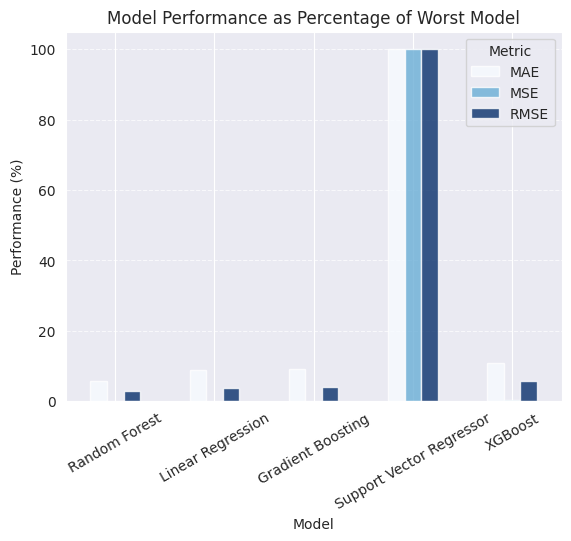

In [27]:
data = {
    "Model": [
        "Random Forest",
        "Linear Regression",
        "Gradient Boosting",
        "Support Vector Regressor",
        "XGBoost",
    ],
    "MAE": [0.183393, 0.281959, 0.296317, 3.221813, 0.348321],
    "MSE": [0.162062, 0.300511, 0.341475, 212.794531, 0.719179],
    "RMSE": [0.402569, 0.548189, 0.584358, 14.587479, 0.848044],
    "R2 Score": [0.999926, 0.999863, 0.999845, 0.903289, 0.999673],
}

df = pd.DataFrame(data)

# Normalize scores to percentages
metrics = ["MAE", "MSE", "RMSE"]
df_norm = df.copy()
for metric in metrics:
    df_norm[metric] = df_norm[metric] / df_norm[metric].max() * 100

# Plot
plt.figure(figsize=(12, 6))
df_norm.set_index("Model")[metrics].plot(kind="bar", colormap="Blues", alpha=0.8)
plt.title("Model Performance as Percentage of Worst Model")
plt.ylabel("Performance (%)")
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()
